<a href="https://colab.research.google.com/github/ylperdomo/Calculo-Numerico/blob/main/CN_Atividade1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
#Importa as bibliotecas necessárias
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Circle

#Define o estilo visual claro
plt.style.use("seaborn-v0_8-whitegrid")
#Exibe uma mensagem para confimrar a prepração do ambiente
print("Ambiente preparado com sucesso!")

def mostrar(tabela):
    try:
        display(tabela)
    except NameError:
        print(tabela.to_string(index=False))

#Arredonda os valores para n casa decimais
def arredondar(valor, n):
    return np.round(valor, n)

#Trunca valor para n casa decimais sem arredondar
def truncar(valor, n):
  #Calcula o fator que desloca a vírgula decimal
    fator = 10 ** n
    #Trunca o número deslocado e devolve a vírgula a posição original
    return np.trunc(np.asarray(valor) * fator) / fator

#Define uma função que calcula os três tipos de erro
def calcular_erros(referencia, aproximacao):
    #Calcula a distância entre o valor de referência e a aproximação
    ea = np.abs(np.asarray(referencia) - np.asarray(aproximacao))
    #Divide o erro absoluto pelo módulo do valor de referência
    er = ea / np.abs(np.asarray(referencia))
    #Converte o erro relativo em porcentagem
    ep = 100 * er
    #Deolve os três erros calculados
    return ea, er, ep


Ambiente preparado com sucesso!


# Parte A - Truncamento e arredondamento

Valores fornecidos:

$$x_1=3{,}14159265,\qquad x_2=98{,}76543,\qquad x_3=0{,}00498765$$

Para cada número, serão usadas $n=0,1,2,3,4$ casas decimais. Para cada aproximação calcularemos $E_a$, $E_r$ e $E_\%$.

In [18]:
#Cria um dicionário com os três valores fornecidos
valores = {
    'x1': 3.14159265,
    'x2': 98.76543,
    'x3': 0.00498765,
}
#Cria uma lista com as casas decimais
casas_decimais = range(0, 5)

linhas = []

#Percorre cada nome e cada valor do dicionário
for nome, valor in valores.items():
  #Percorre as cinco casas decimais
    for n in casas_decimais:
        aproximacoes = {
            #Calcula a aproximação truncada
            'Truncamento': truncar(valor, n),
            #Calcula a aproximação arredondada
            'Arredondamento': arredondar(valor, n),
        }

        #Percorre cada método de aproximação
        for metodo, aproximacao in aproximacoes.items():
          #Calcula os três erros de aproximação
            ea, er, ep = calcular_erros(valor, aproximacao)
            linhas.append({
                'Valor': valor,
                'Nº de casas decimais': n,
                'Método': metodo,
                'Aproximação': float(aproximacao),
                'Erro absoluto': float(ea),
                'Erro relativo': float(er),
                'Erro percentual': float(ep),
            })

#Cria tabela
tabela = pd.DataFrame(linhas)
mostrar(tabela)

,Valor,Nº de casas decimais,Método,Aproximação,Erro absoluto,Erro relativo,Erro percentual
0,3.141593,0,Truncamento,3.0000,0.141593,4.507034e-02,4.507034
1,3.141593,0,Arredondamento,3.0000,0.141593,4.507034e-02,4.507034
2,3.141593,1,Truncamento,3.1000,0.041593,1.323935e-02,1.323935
3,3.141593,1,Arredondamento,3.1000,0.041593,1.323935e-02,1.323935
4,3.141593,2,Truncamento,3.1400,0.001593,5.069562e-04,0.050696
5,3.141593,2,Arredondamento,3.1400,0.001593,5.069562e-04,0.050696
6,3.141593,3,Truncamento,3.1410,0.000593,1.886464e-04,0.018865
7,3.141593,3,Arredondamento,3.1420,0.000407,1.296635e-04,0.012966
8,3.141593,4,Truncamento,3.1415,0.000093,2.949141e-05,0.002949
9,3.141593,4,Arredondamento,3.1416,0.000007,2.339578e-06,0.000234


KeyError: 'n'

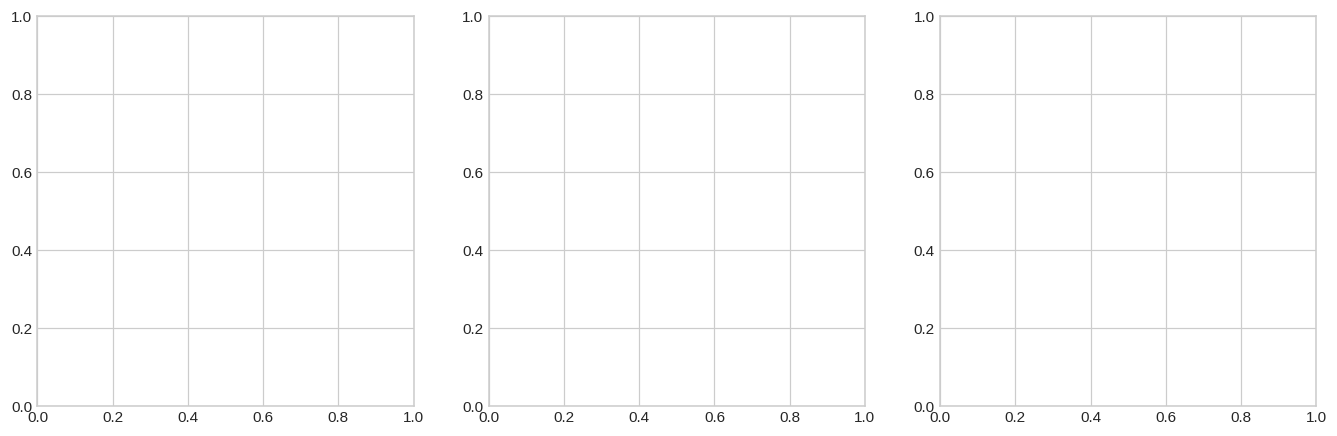

In [16]:
# Gráfico logarítmico do erro absoluto em função de n
fig, eixos = plt.subplots(1, 3, figsize=(15, 4.6))

for eixo, (nome, valor) in zip(eixos, valores.items()):
    dados = tabela[tabela['Valor'] == nome]
    for metodo, estilo in [('Truncamento', '-o'), ('Arredondamento', '--s')]:
        parte = dados[dados['Método'] == metodo]
        eixo.plot(parte['n'], parte['Ea'], estilo, linewidth=2, label=metodo)
    eixo.set_yscale('log')
    eixo.set_title(f'{nome} = {valor}')
    eixo.set_xlabel('Número de casas decimais')
    eixo.set_ylabel('Erro absoluto')
    eixo.set_xticks(list(casas_decimais))
    eixo.grid(True, which='both', alpha=0.3)
    eixo.legend()

fig.suptitle('Parte A - Erro absoluto:runcamento e arredondamento')
plt.tight_layout()
plt.show()

### Resposta da Parte A

Nos resultados da lista, o arredondamento gera erro absoluto menor ou igual ao truncamento. Isso ocorre porque o arredondamento escolhe o valor representável mais próximo na casa decimal solicitada, enquanto o truncamento sempre elimina os algarismos seguintes. Os métodos dão o mesmo erro quando conduzem à mesma aproximação, como ocorre para $x_1$ com $n=0,1,2$ e para $x_2$ com $n=3,4$.